# 03 — The rebalancing mechanism: profit-seeking correction

> Run top to bottom.

Models the thing that actually rebalances the pool: a self-interested arbitrageur who profits by trading our pool's price back toward the real market price (`aqua_sim.flows.maybe_arbitrage_trade`). No special incentive needed — ordinary profit-seeking does the correcting.

This notebook documents a real bug found and fixed while building it (§1), kept in the record on purpose.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from aqua_sim.curve import CurveState, spot_price
from aqua_sim.flows import EndogenousArbConfig, maybe_arbitrage_trade
from aqua_sim.market import simulate_price_path
from aqua_sim.simulate import MechanismSimConfig, run_mechanism_simulation
from aqua_sim.flows import ExogenousFlowConfig
from aqua_sim.metrics import weight_a

## 1. The bug: two reciprocal price conventions

`market.py`'s price ("how many B is 1 A worth", everyday convention) and `curve.py`'s `spot_price` ("units of A paid per unit of B", Balancer-whitepaper convention) are reciprocals of each other. An early version of the simulation loop fed the everyday-convention price directly into the arb logic, which expected the curve convention. The two only coincide at price=1.0 — every early, narrower test happened to use that value, which is why none of them caught it. It only surfaced in the full year-long run (§4), where the pool nearly stopped tracking its target entirely.

The check below locks this in: it tests at a price ≠ 1.0, so the two conventions can't silently hide a mix-up again.

In [2]:
config = EndogenousArbConfig(fee=0.0002, gas_cost_b=0.10)

# Pool already fair at SP(A->B) = 4.0 (400 A paid... i.e. 400/100 = 4 A per B received).
fair_state = CurveState(balance_in=400, balance_out=100, weight_in=0.5, weight_out=0.5)
assert abs(spot_price(fair_state) - 4.0) < 1e-9

_, _, happened_fair = maybe_arbitrage_trade(fair_state, market_price=4.0, config=config, steps_since_last_trade=999)
assert not happened_fair, "a pool already at the market's own SP convention value must not trade"

# Its reciprocal (0.25) must be detected as a real divergence, in one orientation or the other.
_, _, happened_same = maybe_arbitrage_trade(fair_state, market_price=0.25, config=config, steps_since_last_trade=999)
flipped = CurveState(fair_state.balance_out, fair_state.balance_in, fair_state.weight_out, fair_state.weight_in)
_, _, happened_flipped = maybe_arbitrage_trade(flipped, market_price=4.0, config=config, steps_since_last_trade=999)
assert happened_same or happened_flipped, "feeding the reciprocal price must be caught as a divergence somewhere"

print(f"fair price (4.0): no trade fires (correct)")
print(f"reciprocal (0.25): caught as a divergence (same-orientation={happened_same}, flipped={happened_flipped})")
print("This exact check, with market_price=1.0, would have passed either way -- which is why it didn't catch the bug originally.")

fair price (4.0): no trade fires (correct)
reciprocal (0.25): caught as a divergence (same-orientation=False, flipped=True)
This exact check, with market_price=1.0, would have passed either way -- which is why it didn't catch the bug originally.


## 2. Correction runs in the right direction, both ways

Whichever side is skewed cheap, the profitable trade direction should push the pool's price back toward the real market price, without overshooting it. Checked both directions (a pool can be off-target either way).

In [3]:
# Below market: SP(A->B) = 80/120 = 0.667 vs market 1.0 -- pool is cheap, arb buys B.
below = CurveState(balance_in=80, balance_out=120, weight_in=0.5, weight_out=0.5)
sp_before = spot_price(below)
new_below, _, happened = maybe_arbitrage_trade(below, market_price=1.0, config=config, steps_since_last_trade=999)
assert happened
sp_after = spot_price(new_below)
assert sp_after > sp_before, "SP(A->B) should move UP toward market"
assert sp_after <= 1.0 + 1e-6, "should not overshoot past market"
print(f"below-market case: SP(A->B) {sp_before:.4f} -> {sp_after:.4f} (target 1.0) -- correct direction, no overshoot")

# Above market: SP(A->B) = 120/80 = 1.5 vs market 1.0 -- the A->B orientation is now the
# WRONG (unprofitable) one; the flipped B->A orientation is the profitable direction.
above = CurveState(balance_in=120, balance_out=80, weight_in=0.5, weight_out=0.5)
_, _, happened_wrong = maybe_arbitrage_trade(above, market_price=1.0, config=config, steps_since_last_trade=999)
assert not happened_wrong, "A->B should not fire when SP(A->B) is already above market"

above_flipped = CurveState(above.balance_out, above.balance_in, above.weight_out, above.weight_in)
sp_before2 = spot_price(above_flipped)
new_flipped, _, happened2 = maybe_arbitrage_trade(above_flipped, market_price=1.0, config=config, steps_since_last_trade=999)
assert happened2
sp_after2 = spot_price(new_flipped)
assert sp_after2 > sp_before2 and sp_after2 <= 1.0 + 1e-6
print(f"above-market case (flipped orientation): SP(B->A) {sp_before2:.4f} -> {sp_after2:.4f} (target 1.0) -- correct direction, no overshoot")

below-market case: SP(A->B) 0.6667 -> 1.0000 (target 1.0) -- correct direction, no overshoot
above-market case (flipped orientation): SP(B->A) 0.6667 -> 1.0000 (target 1.0) -- correct direction, no overshoot


## 3. No tolerance band, no rate cap — a gas-cost profitability gate instead

Per `ADR-0006` (revised after a real sweep, not a guess): a separate hand-picked dead-zone and cooldown turned out to be redundant once correction is gated on real economics. The fee alone already creates a no-arbitrage zone (a drift too small to clear it isn't worth correcting); adding a real gas cost on top raises that bar further, without needing an artificial cooldown timer -- there's no rate cap in this design at all.

In [4]:
# The fee alone creates a no-arbitrage zone -- a drift too small to clear the 2bps fee
# doesn't fire, with no separate hand-picked dead-zone needed.
tiny_drift = CurveState(balance_in=100, balance_out=100.005, weight_in=0.5, weight_out=0.5)
_, _, happened_tiny = maybe_arbitrage_trade(tiny_drift, market_price=1.0, config=config, steps_since_last_trade=999)
assert not happened_tiny
print("drift too small to clear the fee: no trade fires (correct)")

# No rate cap either: a large-enough skew fires immediately, even right after a previous trade.
_, _, happened_immediate = maybe_arbitrage_trade(below, market_price=1.0, config=config, steps_since_last_trade=0)
assert happened_immediate, "no cooldown in the settled design -- a real skew should fire on the very next step"
print("large skew fires immediately, with no cooldown blocking it (correct -- ADR-0006 settled on no rate cap)")

# Gas cost matters at real (non-toy) scale: pass a real gas_cost_in and show a small-but-real
# drift stops being worth correcting once gas is priced in.
real_scale = CurveState(balance_in=10_000, balance_out=10_010, weight_in=0.5, weight_out=0.5)
_, _, happened_no_gas = maybe_arbitrage_trade(real_scale, market_price=1.0, config=config, steps_since_last_trade=999, gas_cost_in=0.0)
_, _, happened_with_gas = maybe_arbitrage_trade(real_scale, market_price=1.0, config=config, steps_since_last_trade=999, gas_cost_in=config.gas_cost_b)
print(f"same drift, no gas priced in: fires={happened_no_gas}; with a real ${config.gas_cost_b} gas cost: fires={happened_with_gas}")

drift too small to clear the fee: no trade fires (correct)
large skew fires immediately, with no cooldown blocking it (correct -- ADR-0006 settled on no rate cap)
same drift, no gas priced in: fires=True; with a real $0.1 gas cost: fires=False


## 4. A full simulated year, end to end

The test that originally caught §1's bug: a full year of background noise (notebook 02) + corrective trading, against a synthetic (not historical) price path. `N_STEPS` is the actual simulated unit -- `STEP_MINUTES` below is an illustrative real-world duration assigned to each step for readability (print statements, plot axes), not a modeled chain timing fact; nothing about chain block times or confirmation latency is simulated here. Checked: tracking error stays small and bounded, driven purely by the fee + gas-cost economics, no configured band.

In [5]:
STEP_MINUTES = 5  # illustrative real-world duration per step -- not modeled chain timing
STEPS_PER_YEAR = 365 * 24 * 60 // STEP_MINUTES
N_STEPS = STEPS_PER_YEAR  # the actual simulated unit is the step, not a real-world duration
DT = 1 / STEPS_PER_YEAR

sim_config = MechanismSimConfig(
    n_steps=N_STEPS,
    dt_years=DT,
    sigma_annual=0.8,
    initial_balance_a=10_000.0,
    initial_balance_b=10_000.0,
    target_weight_a=0.5,
    exogenous=ExogenousFlowConfig(arrival_rate_per_year=365 * 4, mean_size_fraction=0.01),
    arb=EndogenousArbConfig(fee=0.0002, gas_cost_b=0.10),
    seed=42,
)

result = run_mechanism_simulation(sim_config)

assert np.all(result.balance_a_path > 0) and np.all(result.balance_b_path > 0)
p95_te = np.percentile(result.tracking_error_path, 95)
assert p95_te < 0.05, f"95th percentile tracking error should be well-bounded by the tolerance band, got {p95_te}"

print(f"{result.n_exogenous_trades} exogenous + {result.n_arb_trades} arb trades over {N_STEPS} steps")
print(f"price path range: {result.price_path.min():.3f} to {result.price_path.max():.3f} (started at 1.0)")
print(f"95th percentile tracking error: {p95_te:.4%}")
print(f"final cost of rebalancing: {result.cost_path[-1]:.2f} ({result.cost_path[-1]/result.actual_value_path[0]:.2%} of initial value {result.actual_value_path[0]:.2f})")

1492 exogenous + 10224 arb trades over 105120 steps
price path range: 0.200 to 2.005 (started at 1.0)
95th percentile tracking error: 0.1551%
final cost of rebalancing: 705.49 (3.53% of initial value 20000.00)


## Visuals

Synthetic price path; tracking error vs. the tolerance band; actual portfolio value vs. a frictionless (instant, free) rebalancing reference; and that gap plotted as cumulative cost.

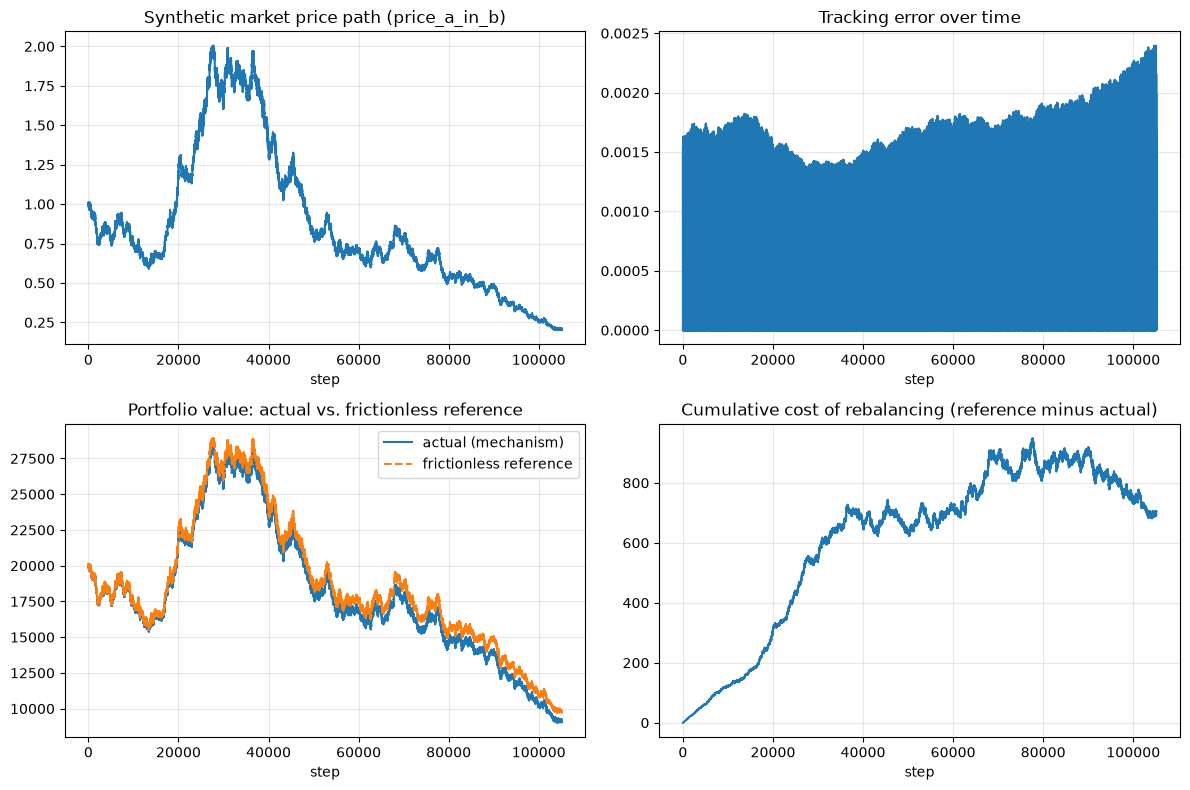

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(result.price_path)
axes[0, 0].set_title("Synthetic market price path (price_a_in_b)")
axes[0, 0].set_xlabel("step")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(result.tracking_error_path)
axes[0, 1].set_title("Tracking error over time")
axes[0, 1].set_xlabel("step")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(result.actual_value_path, label="actual (mechanism)")
axes[1, 0].plot(result.reference_value_path, label="frictionless reference", linestyle="--")
axes[1, 0].set_title("Portfolio value: actual vs. frictionless reference")
axes[1, 0].set_xlabel("step")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(result.cost_path)
axes[1, 1].set_title("Cumulative cost of rebalancing (reference minus actual)")
axes[1, 1].set_xlabel("step")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

1. Found and fixed a real price-convention bug (§1) — now permanently guarded by a non-1.0 regression check.
2. Correction runs the right direction both ways, without overshoot.
3. No tolerance band, no rate cap -- a real gas-cost profitability gate does the job instead.
4. A full simulated year stays bounded and self-correcting.

This shows the mechanism works under our synthetic price model with idealized arbitrageurs — stronger than notebook 01's pure safety claim, but not yet a real-money guarantee (caveats in `05_frontier_sweep.ipynb`'s summary). Only a single token pair is modeled; multi-token group routing isn't built yet.

Next: `04_naive_baselines.ipynb` builds the alternatives this mechanism has to beat.